### 第18章 绘图及交互
#### 18.1 绘图基础
##### 1. 函数共有参数
- `img` 绘制图形的载体图像（绘图的容器，也称为画布、画板等）
- `color` 绘制形状的颜色，使用 BGR 模型表示颜色。对于灰度图像，只能传入单个灰度值
- `thickness` 线条的粗细，默认值是 1，如果设置为 -1，表示填充图形（即实心图形）
- `lineType` 线条的类型
    - `cv2.FILLED` 填充
    - `cv2.LINE_4` 4 连接类型
    - `cv2.LINE_8` 8 连接类型（默认）
    - `cv2.LINE_AA` 抗锯齿，让线条更平滑
- `shift` 数据精度，一般情况下，该参数可选，不需要设置

##### 2. 绘制图形
- 函数 `img = cv2.line(img, pt1, pt2, color[, thickness[, lineType]])` 用来绘制直线，其中
    - `pt1` 表示线段的第1个点（起点）
    - `pt2` 表示线段的第2个点（终点）

- 函数 `img = cv2.rectangle(img, pt1, pt2, color[, thickness[, lineType]])` 用来绘制矩形，其中
    - `pt1` 为矩形顶点
    - `pt2` 为矩形中 `pt1` 的对角顶点

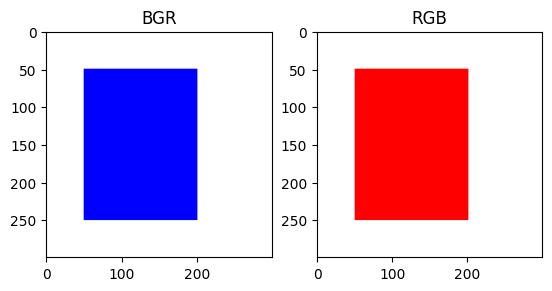

In [4]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

# 在白色背景内绘制实心矩形
n = 300
img = np.ones((n, n, 3), np.uint8) * 255
img = cv2.rectangle(img, (50, 50), (n - 100, n - 50), (0, 0, 255), -1)
plt.subplot(121)
plt.imshow(img)
plt.title("BGR")
img2 = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.subplot(122)
plt.imshow(img2)
plt.title("RGB")
plt.show()

- 函数 `img = cv2.circle(img, center, radius, color[, thickness[, lineType]])` 用来绘制圆形，其中
    - `center` 为圆心
    - `radius` 为半径

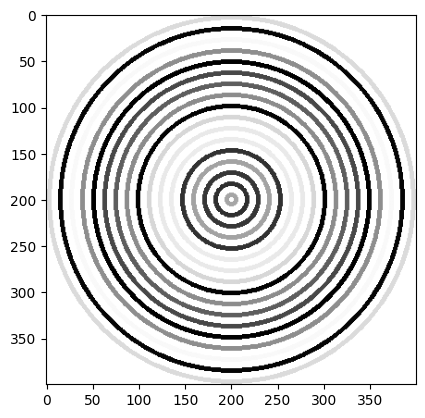

In [8]:
# 在白色背景内绘制一组同心圆
import numpy as np
import cv2
import matplotlib.pyplot as plt

d = 400
img = np.ones((d, d), dtype="uint8") * 255  # 单通道灰度图像
(centerX, centerY) = (round(img.shape[1] / 2), round(img.shape[0] / 2))
# 将图像的中心作为圆心,实际值为=d/2
for r in range(5, round(d / 2), 12):
    randColor = np.random.randint(0, 256)
    cv2.circle(img, (centerX, centerY), r, randColor, 3)
    # circle(载体图像，圆心，半径，颜色)
plt.imshow(img, cmap="gray")
# plt.axis("off")
plt.show()

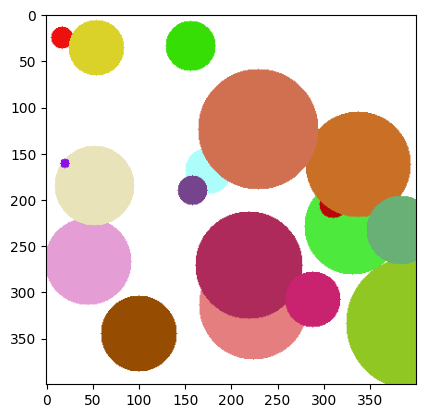

In [13]:
# 在白色背景内绘制一组位置、大小、颜色均随机的实心圆
import numpy as np
import cv2
import matplotlib.pyplot as plt

d = 400
img = np.ones((d, d, 3), dtype="uint8") * 255
# 生成白色背景
for i in range(0, 20):
    centerX = np.random.randint(0, high=d)
    # 生成随机圆心X,确保在画布img内
    centerY = np.random.randint(0, high=d)
    # 生成随机圆心Y,确保在画布img内
    radius = np.random.randint(5, high=d / 5)
    # 生成随机半径，值范围：[5,d/5)，最大半径是d/5
    color = np.random.randint(0, high=256, size=(3,)).tolist()
    # 生成随机颜色，3个[0,256)的随机数
    cv2.circle(img, (centerX, centerY), radius, color, -1)
    # 使用上述随机数，在画布img内画圆
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img)
# plt.axis("off")
plt.show()

- 函数 `img = cv2.ellipse(img, center, axes, angle, startAngle, endAngle, color[, thickness[, lineType]])` 用来绘制椭圆，其中
    - `center` 为椭圆的中心坐标
    - `axes` 为轴的长度
    - `angle` 为偏转的角度
    - `startAngle` 为圆弧起始角的角度
    - `endAngle` 为圆弧终止角的角度

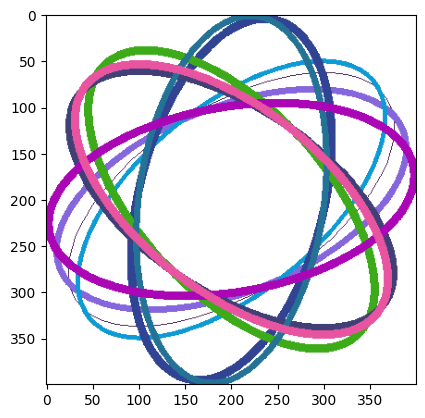

In [ ]:
# 在白色背景内绘制一组位置、大小、颜色均随机的空心椭圆
import numpy as np
import cv2
import matplotlib.pyplot as plt

d = 400
img = np.ones((d, d, 3), dtype="uint8") * 255
# 生成白色背景
center = (round(d / 2), round(d / 2))  # 注意数值类型，不可以使用center=(d/2,d/2)
axes = (100, 200)
# 轴的长度
for i in range(0, 10):
    angle = np.random.randint(0, 361)
    # 偏移角度
    color = np.random.randint(0, high=256, size=(3,)).tolist()
    # 生成随机颜色，3个[0,256)的随机数
    thickness = np.random.randint(1, 9)
    cv2.ellipse(img, center, axes, angle, 0, 360, color, thickness)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img)
plt.show()

- 函数 `img = cv2.polylines(img, pts, isClosed, color[, thickness[, lineType]])` 用来绘制多边形，其中
    - `pts` 为多边形的各个顶点
    - `isClosed` 为闭合标记。若该值为 `True`，则将最后一个点与第一个点连接；否则，仅将各个点依次连接构成一条曲线

pts original shape:
 (4, 2)
pts new shape:
 (4, 1, 2)


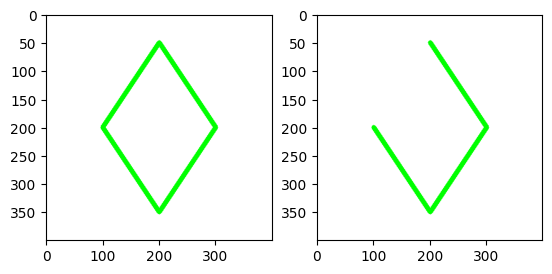

In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

d = 400
img = np.ones((d, d, 3), dtype="uint8") * 255
# 生成白色背景
pts = np.array([[200, 50], [300, 200], [200, 350], [100, 200]], np.int32)
print("pts original shape:\n", pts.shape)
# 生成各个顶点,注意数据类型为int32
pts = pts.reshape((-1, 1, 2))
print("pts new shape:\n", pts.shape)
# 第1个参数为-1, 表明这一维的长度是根据后面的维度的计算出来的。
img_copy = img.copy()
cv2.polylines(img, [pts], True, (0, 255, 0), 8)
# 调用函数polylines完成多边形绘图，注意第3个参数控制多边形封闭
cv2.polylines(img_copy,[pts], False, (0,255,0), 8)  #不闭合的的多边形

img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img_copy = cv2.cvtColor(img_copy, cv2.COLOR_BGR2RGB)

plt.subplot(121)
plt.imshow(img)
plt.subplot(122)
plt.imshow(img_copy)
plt.show()

- 函数 `img = cv2.putText(img, text, org, fontFace, fontScale, color[, thickness[, lineType[, bottomLeftOrigin]]])` 用来在图形上绘制文字，其中
    - `text` 表示要绘制的文本
    - `org` 为绘制字体的位置。该参数控制文字的左下角位置，是文字在图像中的起点
    - `fontFace` 表示字体类型
    - `fontScale` 表示字体大小
    - `bottomLeftOrigin` 用于控制文字的起始位置。
        - 当该值为 `True` 时，从左上角开始绘制，可实现文字的镜像效果
        - 当该值为 `False` 时，从左下角开始绘制，默认值是 `False`

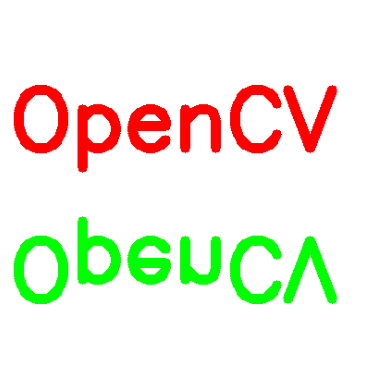

In [30]:
import numpy as np
import cv2

d = 400
img = np.ones((d, d, 3), dtype="uint8") * 255
# 生成白色背景
font = cv2.FONT_HERSHEY_SIMPLEX
cv2.putText(img, "OpenCV", (0, 150), font, 3, (0, 0, 255), 10)
cv2.putText(img, "OpenCV", (0, 250), font, 3, (0, 255, 0), 10, cv2.FONT_HERSHEY_SCRIPT_SIMPLEX, True)

img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img)
plt.axis("off")
plt.show()